## Description
_______

This script generates a bar and whiskers plot for every ESP output found in the directory_path folder.  
The plot includes observed streamflow and optionally, simulated streamflow from a full model run.  
Plot will be generated for date between start_date and end_date so that performance of different forecast  
lead times can be analyzed. 

### Import Libraries

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import networkx as nx

In [2]:
# Inputs
geodata= pd.read_csv('../state_model/GeoData.txt', index_col=0, sep='\t')

fca = pd.read_csv('../hist_data/timeFCON_DD.txt', sep= '\t', skiprows=1, index_col=0)

cilv = pd.read_csv('../hist_data/timeCILV_DD.txt', sep= '\t', skiprows=1, index_col=0)

prec= pd.read_csv('../hist_data/timeCPRC_DD.txt', sep= '\t',skiprows=1, index_col=0)

In [3]:
plot_configs = [
    {
        'dir_path': './esp_init_results/apr1_start_sep30_end/58208_esp_results/',
        'computed_path': '../hist_data/full/0058208.txt',
        'start_date': '04-01',
        'end_date': '07-31',
        'title': 'St. Mary: SMRIB',
        'gauge_id': 58208,
    },
        {
        'dir_path': './esp_init_results/apr1_start_sep30_end/58213_esp_results/',
        'computed_path': '../hist_data/full/0058213.txt',
        'start_date': '04-01',
        'end_date': '07-31',
        'title': 'St. Mary: SMRBB',
        'gauge_id': 58213,
    },
    {
        'dir_path': './esp_init_results/feb1_start_sep30_end/58290_esp_results/',
        'computed_path': '../hist_data/full/0058290.txt',
        'start_date': '02-01',
        'end_date': '05-31',
        'title': 'Milk River: FRRIB',
        'gauge_id': 58290,
    },
        {
        'dir_path': './esp_init_results/feb1_start_sep30_end/58308_esp_results/',
        'computed_path': '../hist_data/full/0058308.txt',
        'start_date': '02-01',
        'end_date': '05-31',
        'title': 'Milk River: MREIB',
        'gauge_id': 58308,
    },
        {
        'dir_path': './esp_init_results/feb1_start_sep30_end/58356_esp_results/',
        'computed_path': '../hist_data/full/0058356.txt',
        'start_date': '02-01',
        'end_date': '05-31',
        'title': 'Milk River: LDCIB',
        'gauge_id': 58356,
    },
        {
        'dir_path': './esp_init_results/feb1_start_sep30_end/58363_esp_results/',
        'computed_path': '../hist_data/full/0058363.txt',
        'start_date': '02-01',
        'end_date': '05-31',
        'title': 'Milk River: BTCIB',
        'gauge_id': 58363,
    },


]

output_path = './new_plots/'


Processing 0 - St. Mary: SMRIB
Processing 1 - St. Mary: SMRBB
Processing 2 - Milk River: FRRIB
Processing 3 - Milk River: MREIB
Processing 4 - Milk River: LDCIB
Processing 5 - Milk River: BTCIB


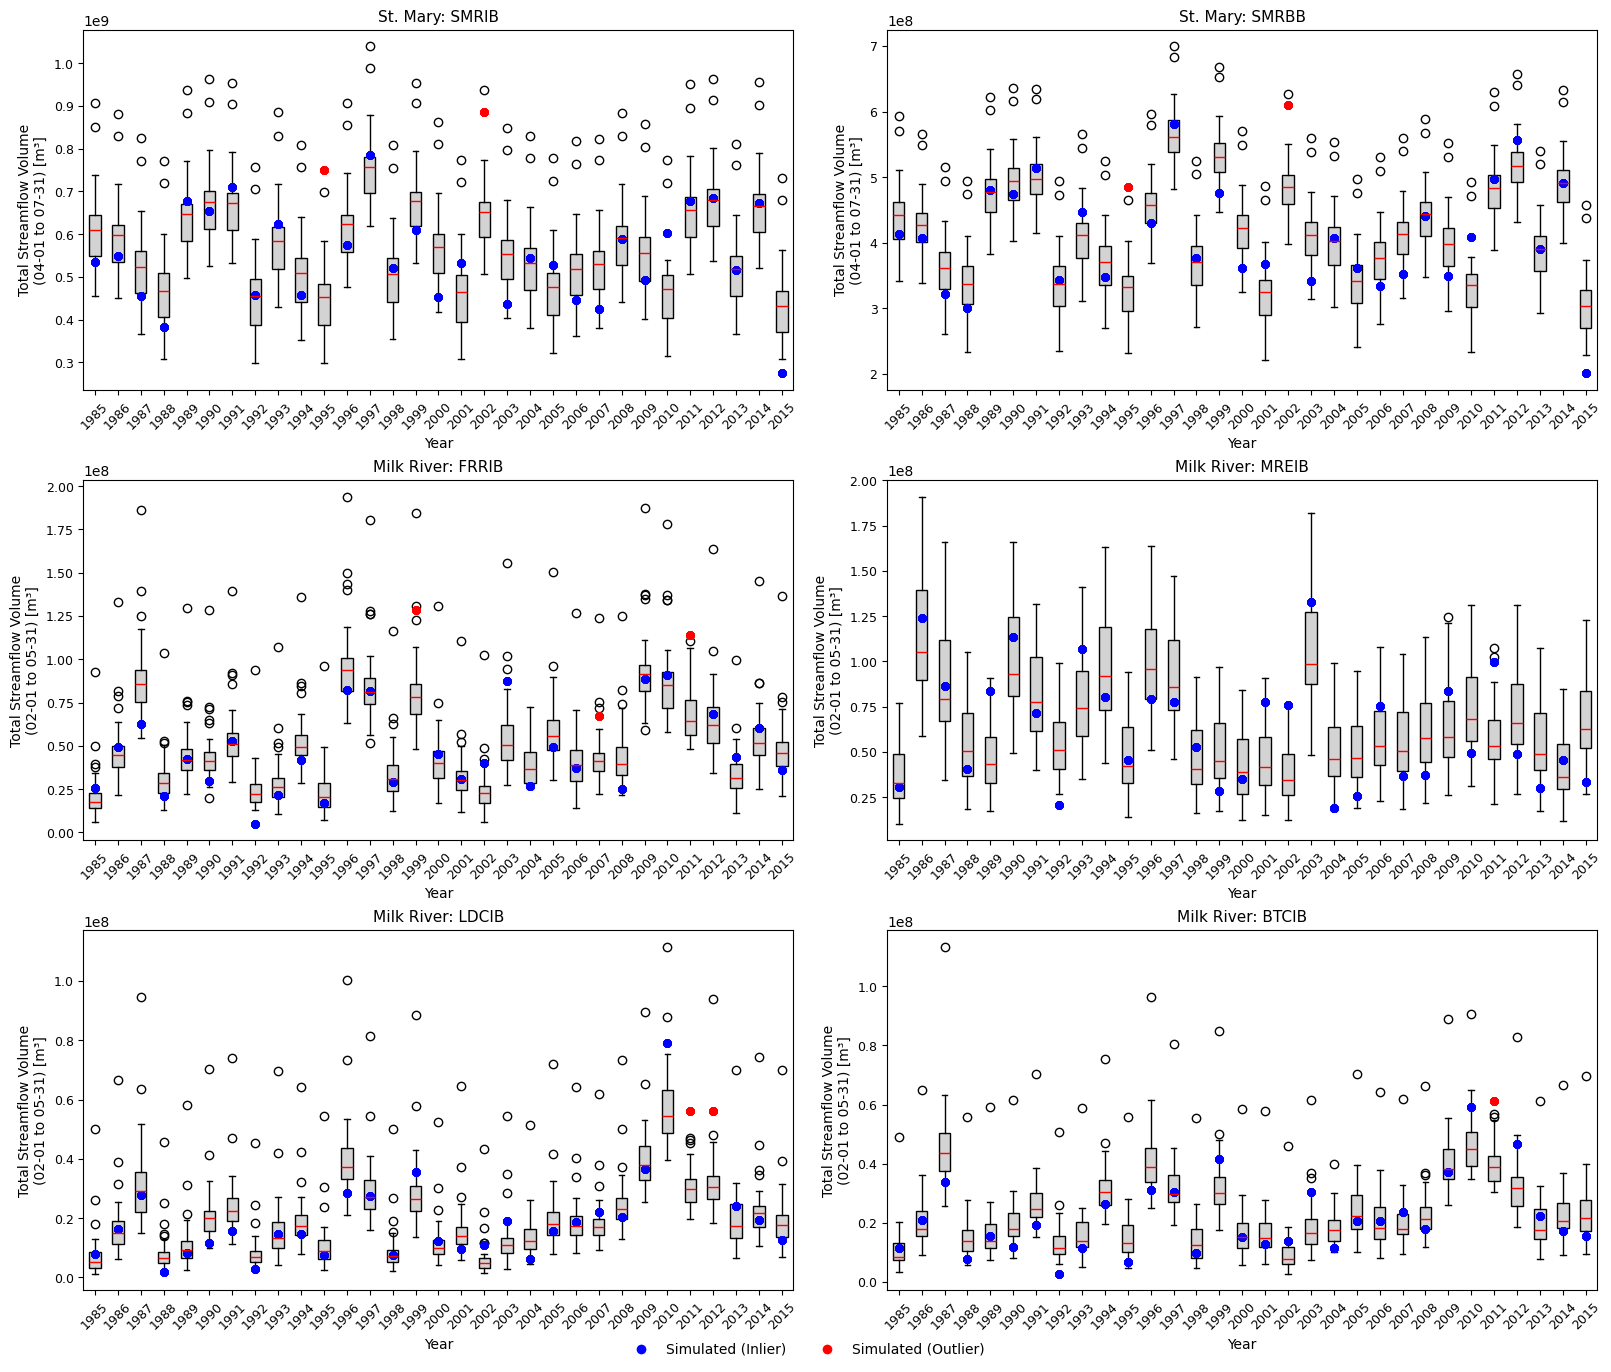

In [8]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import os
import pandas as pd
import numpy as np
import xarray as xr

SECONDS_PER_DAY = 86400

def process_and_plot(config, ax):
    directory_path = config['dir_path']
    computed_path = config['computed_path']
    start_date = config['start_date']
    end_date = config['end_date']
    plot_title = config['title']

    start_month, start_day = map(int, start_date.split('-'))
    end_month, end_day = map(int, end_date.split('-'))

    all_sum_cout_series = []
    sum_model_sim = []

    # Read observed full-model simulation
    sim = pd.read_csv(computed_path, sep='\t', index_col=0)
    sim = sim.drop('UNITS', axis=0)
    sim.index = pd.to_datetime(sim.index, errors='coerce')
    sim['cout'] = pd.to_numeric(sim['cout'], errors='coerce')

    for filename in os.listdir(directory_path):
        if filename.endswith('.nc'):
            file_path = os.path.join(directory_path, filename)
            esp = xr.open_dataset(file_path).astype(float)
            esp['DATE'] = pd.to_datetime(esp['DATE'])

            last_year = pd.to_datetime(esp['DATE'][-1].values).year
            start_dt = pd.Timestamp(year=last_year, month=start_month, day=start_day)
            end_dt = pd.Timestamp(year=last_year, month=end_month, day=end_day)

            ds_selected = esp.sel(DATE=slice(start_dt, end_dt))
            sum_cout = (ds_selected['cout'] * SECONDS_PER_DAY).sum(dim='DATE')
            sum_cout_series = sum_cout.to_series()
            sum_cout_series.index = pd.to_datetime(sum_cout_series.index)
            sum_cout_series.index = sum_cout_series.index.map(lambda x: x.replace(year=last_year))
            all_sum_cout_series.append(sum_cout_series)

            model_sim = sim.loc[start_dt:end_dt]
            sum_sim = (model_sim['cout'] * SECONDS_PER_DAY).sum()
            sim_series = sum_cout_series.copy()
            sim_series[:] = sum_sim
            sim_series.name = 'sim'
            sum_model_sim.append(sim_series)

    if not all_sum_cout_series:
        ax.set_title(f"{plot_title}\n(No .nc files found)", fontsize=10)
        return []

    sum_cout_series_combined = pd.concat(all_sum_cout_series)
    sum_model_sim_combined = pd.concat(sum_model_sim)

    years_sorted = sorted(sum_cout_series_combined.index.year.unique())
    data = [sum_cout_series_combined[sum_cout_series_combined.index.year == year].values for year in years_sorted]

    ax.boxplot(data, patch_artist=True, medianprops=dict(color='red'),
               boxprops=dict(color='black', facecolor='lightgray'))

    ax.set_xticks(range(1, len(years_sorted)+1))
    ax.set_xticklabels(years_sorted, rotation=45, fontsize=9)
    ax.set_title(plot_title, fontsize=11)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(f'Total Streamflow Volume\n({start_month:02d}-{start_day:02d} to {end_month:02d}-{end_day:02d}) [m³]', fontsize=10)

    outlier_records = []
    for i, year in enumerate(years_sorted, start=1):
        year_data = sum_cout_series_combined[sum_cout_series_combined.index.year == year].values
        q1, q3 = np.percentile(year_data, 25), np.percentile(year_data, 75)
        iqr = q3 - q1
        lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
        y_sim = sum_model_sim_combined[sum_model_sim_combined.index.year == year].values
        x_sim = np.random.normal(i, 0.00001, size=len(y_sim))
        inliers = (y_sim >= lower_bound) & (y_sim <= upper_bound)
    
        ax.plot(x_sim[inliers], y_sim[inliers], 'b.', alpha=0.5, markersize=10)
        ax.plot(x_sim[~inliers], y_sim[~inliers], 'r.', alpha=0.5, markersize=10)
    
        median_val = np.median(year_data)
        if np.any(~inliers):
            val = y_sim[0]
            outlier_records.append({
                'title': plot_title,
                'year': year,
                'sim_value': val,
                'median': median_val,
                'difference': val - median_val,
            })

    return outlier_records


# # -----------------------------
# # Generate Subplots — 2-col grid
# # -----------------------------
# ncols = 2
# nrows = int(np.ceil(len(plot_configs) / ncols))   # 3 rows for 6 configs

# fig_width  = 16
# fig_height = 5 * nrows      # ← was 7, makes each panel ~4" tall vs ~8" wide

# fig, axes = plt.subplots(
#     nrows=nrows, ncols=ncols,
#     figsize=(fig_width, fig_height),
#     constrained_layout=False
# )

# # Flatten to a 1-D list so the loop stays identical
# axes_flat = axes.flatten()

# all_outlier_info = []
# for i, (ax, config) in enumerate(zip(axes_flat, plot_configs)):
#     print(f'Processing {i} - {config["title"]}')
#     outliers = process_and_plot(config, ax)
#     all_outlier_info.extend(outliers)
#     ax.set_xlabel('Year', fontsize=10)
#     ax.tick_params(axis='x', labelsize=9)
#     ax.tick_params(axis='y', labelsize=9)

# # Hide any unused axes (if plot_configs count is odd)
# for ax in axes_flat[len(plot_configs):]:
#     ax.set_visible(False)

# # Spacing — more horizontal room between columns, modest vertical gap
# fig.subplots_adjust(hspace=0.45, wspace=0.3, bottom=0.08)   # ← hspace back up slightly to accommodate rotated xlabels in less vertical space

# # -----------------------------
# # Global Legend below plots
# # -----------------------------
# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', label='Simulated (Inlier)',
#            markerfacecolor='blue', markersize=8),
#     Line2D([0], [0], marker='o', color='w', label='Simulated (Outlier)',
#            markerfacecolor='red', markersize=8)
# ]
# fig.legend(handles=legend_elements, loc='lower center', ncol=2,
#            fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.02))

# # -----------------------------
# # Save Outputs
# # -----------------------------
# os.makedirs(output_path, exist_ok=True)
# fig.savefig(os.path.join(output_path, 'fig4_esp_boxplot.png'), dpi=300, bbox_inches='tight')
# fig.savefig(os.path.join(output_path, 'fig4_esp_boxplot.pdf'), dpi=300, bbox_inches='tight')
# plt.show()
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(16, 4.5 * nrows),
    constrained_layout=True        # ← handles all spacing automatically
)

axes_flat = axes.flatten()

all_outlier_info = []
for i, (ax, config) in enumerate(zip(axes_flat, plot_configs)):
    print(f'Processing {i} - {config["title"]}')
    outliers = process_and_plot(config, ax)
    all_outlier_info.extend(outliers)
    ax.set_xlabel('Year', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

for ax in axes_flat[len(plot_configs):]:
    ax.set_visible(False)

# No subplots_adjust needed — constrained_layout handles it

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Simulated (Inlier)',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Simulated (Outlier)',
           markerfacecolor='red', markersize=8)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.01))

os.makedirs(output_path, exist_ok=True)
fig.savefig(os.path.join(output_path, 'fig4_esp_boxplot.png'), dpi=600, bbox_inches='tight')  # ← dpi 300→600
fig.savefig(os.path.join(output_path, 'fig4_esp_boxplot.pdf'), format='pdf', bbox_inches='tight')
plt.show()